<a href="https://colab.research.google.com/github/tanashoooo/SF251/blob/main/SF_251_In_class_Exercise_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In-Class Exercise 10

Once done, upload to MS Teams

## **Q1**: Regression to the mean with simulated data

In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from plotnine import *

### The Modeling Setup
1. Each student is assumed to have a true ability drawn from a distribution with mean 50 and standard deviation 10.
2. Each student's score on the midterm exam is the sum of two components:
  - the student's true ability
  - a random component with mean 0 and standard deviation 10
3. Likewise, each student's score on the final exam is his or her true ability, plus another, independent, random component.

In [3]:
n = 1000
# Simulate true ability
## loc = mean, scale =sd, size = number of sample
true_ability = np.random.normal(loc= 50, scale = 10, size= n)

# Two noises for two exams
noise_1 = np.random.normal(loc= 0,scale= 10, size= n)
noise_2 = np.random.normal(loc= 0,scale= 10, size= n)

# Modeling midterm and final outcome
midterm = true_ability + noise_1
final = true_ability + noise_2
exams = pd.DataFrame({'midterm': midterm, 'final': final})
exams.head()

,midterm,final
0,61.926853,65.412040
1,44.480344,60.556947
2,39.471293,24.605550
3,41.497583,45.896185
4,72.320586,59.647360


Plot the scatter plot between `midterm` and `final`

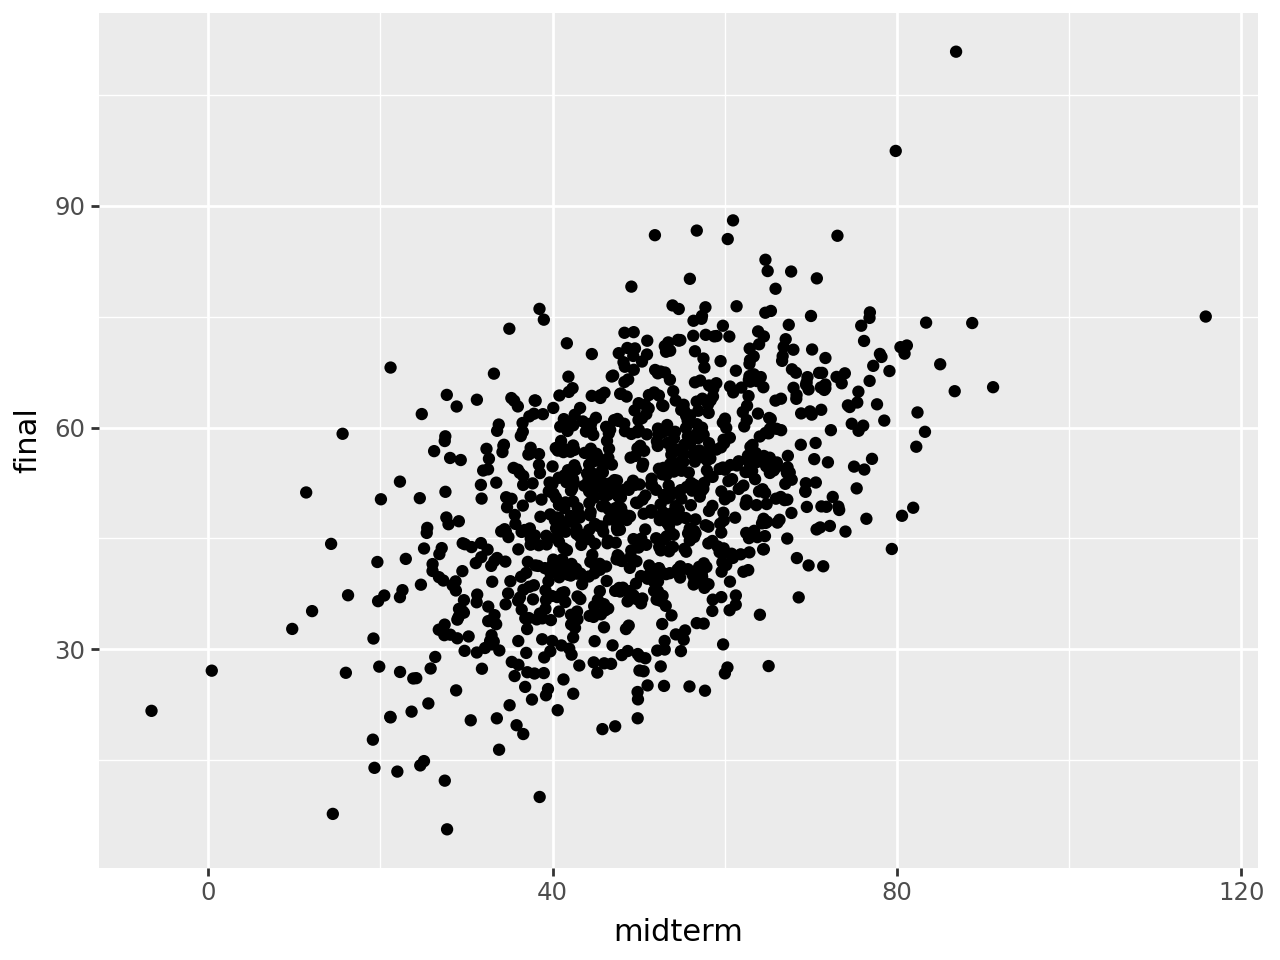

In [5]:
ggplot(exams, aes(x='midterm',y='final')) + geom_point()

Next, fit the linear regression model

In [7]:
model = sm.OLS(exams['final'], sm.add_constant(exams['midterm'])).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  final   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     305.8
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.22e-60
Time:                        07:37:23   Log-Likelihood:                -3896.9
No. Observations:                1000   AIC:                             7798.
Df Residuals:                     998   BIC:                             7808.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.2785      1.413     18.603      0.0

Let's visual the data with the fitted line

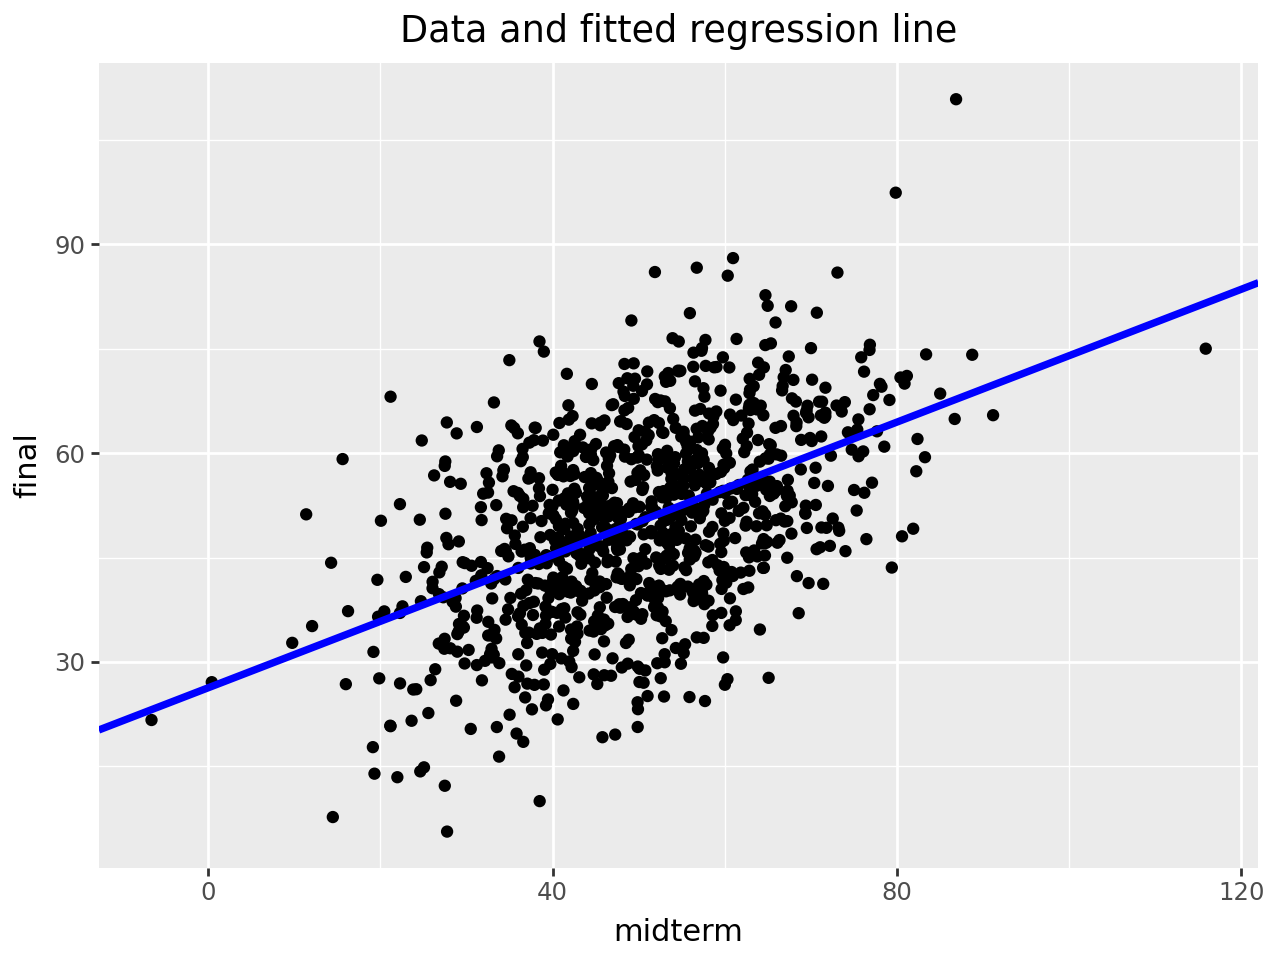

In [8]:
(ggplot(exams, aes(x='midterm',y='final')) +
 geom_point() +                                   # scatter plot
 geom_abline(intercept=model.params['const'], slope=model.params['midterm'], color='blue', size = 1.5) +      # regression line
 ggtitle("Data and fitted regression line"))

Back to the slide

## Pokemon Dataset Part 10

Let's try to interpret the model

In [9]:
!wget https://raw.githubusercontent.com/yongsa-nut/SF251_67_2/refs/heads/main/data/pokemon.csv

--2026-04-10 07:37:28--  https://raw.githubusercontent.com/yongsa-nut/SF251_67_2/refs/heads/main/data/pokemon.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 331632 (324K) [text/plain]
Saving to: ‘pokemon.csv’

pokemon.csv         100%[===================>] 323.86K  --.-KB/s    in 0.03s   

2026-04-10 07:37:28 (10.1 MB/s) - ‘pokemon.csv’ saved [331632/331632]



In [10]:
#Load the data
pokemon = pd.read_csv("pokemon.csv")
pokemon.columns

Index(['national_number', 'gen', 'english_name', 'japanese_name',
       'primary_type', 'secondary_type', 'classification', 'percent_male',
       'percent_female', 'height_m', 'weight_kg', 'capture_rate',
       'base_egg_steps', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense',
       'speed', 'abilities_0', 'abilities_1', 'abilities_2',
       'abilities_hidden', 'against_normal', 'against_fire', 'against_water',
       'against_electric', 'against_grass', 'against_ice', 'against_fighting',
       'against_poison', 'against_ground', 'against_flying', 'against_psychic',
       'against_bug', 'against_rock', 'against_ghost', 'against_dragon',
       'against_dark', 'against_steel', 'against_fairy', 'is_sublegendary',
       'is_legendary', 'is_mythical', 'evochain_0', 'evochain_1', 'evochain_2',
       'evochain_3', 'evochain_4', 'evochain_5', 'evochain_6', 'gigantamax',
       'mega_evolution', 'mega_evolution_alt', 'description'],
      dtype='object')

**Q1**: Relationship between pokemon's hp (`hp`) and their weight (`weight_kg`)
- Fit a linear regression using `sm.OLS` where y is hp and x is weight.
- Print out the model summary

In [ ]:
model = ...
print(model.summary())

**Q2**: Write down the interpretation of the result below

Answer:

**Q3**: Relationship between pokemon's hp and their weight and height

In [ ]:
model = ...
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     hp   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     142.6
Date:                Sat, 04 Jan 2025   Prob (F-statistic):           1.79e-54
Time:                        07:12:14   Log-Likelihood:                -4082.7
No. Observations:                 898   AIC:                             8171.
Df Residuals:                     895   BIC:                             8186.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.1121      1.061     54.766      0.0

**Q4**: Write down the interpreation of the result below

Answer: